# Visualisation of embeddings' distributions

## Requirements

In [37]:
import os
import sys
import json
from typing import Dict
from pathlib import Path
sys.path.insert(0, os.path.join("..", "..", "src"))

import deeplake
import numpy as np
import pandas as pd
import seaborn as sns
from umap import UMAP
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt



# ==================
#   PATH CONSTANTS
# ==================
import os
from pathlib import Path
ROOT_DIR = "/home/leolr-int/nfs/AGGCPerturbations"
#ROOT_DIR = str(Path(__file__).resolve().parents[2])
SRC_DIR = os.path.join(ROOT_DIR, "src")
ASSET_DIR = os.path.join(ROOT_DIR, "assets")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")
PROFILING_DIR = os.path.join(ROOT_DIR, "profiling")
#DATA_DIR = os.path.join(ROOT_DIR, "data")
#DATA_DIR = '/home/leolr-int/nfs/data/data'
DATA_DIR = '/home/leolr-int/nfs/transformed_data/KFBio_FDA_deeplake'
RAW_DIR = os.path.join(DATA_DIR, "raw")
RUN_DIR = os.path.join(ROOT_DIR, "tensorboard")
SPLIT_DIR = os.path.join(DATA_DIR, "splits")
CONFIG_DIR = os.path.join(ROOT_DIR, "configs")
PATCH_DIR = os.path.join(DATA_DIR, "patched")
#METADATA_DIR = os.path.join(DATA_DIR, "metadata")
METADATA_DIR = '/home/leolr-int/nfs/data/data/metadata'
#EMBEDDING_DIR = os.path.join(ROOT_DIR, "embeddings")
EMBEDDING_DIR = '/home/leolr-int/nfs/transformed_data/new_embeddings'

PATCH_TABLE_DIR = os.path.join(DATA_DIR, "patch_tables")
BASE_MODEL_DIR = os.path.join(ROOT_DIR, "model_weights")
FULL_PATCH_DIR = os.path.join(DATA_DIR, "patched_full") # only used for downstream analysis
HISTOGRAM_DIR = os.path.join(DATA_DIR, "histogram_matching_stats")
COMBINED_PATCH_DIR = os.path.join(DATA_DIR, "patched_combined")

LABEL_MAP = {
    "Stroma": 0,
    "Normal": 1,
    "G3":     2,
    "G4":     3,
    "G5":     4
}

COLOR_MAP = {
    0: [242, 182, 216],   
    1: [163, 196, 243],  
    2: [255, 213, 128],   
    3: [190, 224, 200],   
    4: [217, 185, 255],   
}

SEVERITY_COLOR_MAP = {
    0: [255, 0,     255],
    1: [51,  0,     255],
    2: [51,  255,   0  ],
    3: [255, 229.5, 0  ],
    4: [255, 0,     0  ]
}



## Visualisation


In [38]:
def subsample(ds, sample_percantage: float, scanner_name: str, label_map: dict) -> pd.DataFrame:
    if not (0 <= sample_percantage <= 1):
        raise ValueError("sample_percantage must be between 0 and 1")

    unique_labels = np.unique(ds["label"][:]).tolist()
    embeddings, labels, scanners = [], [], []

    for label in tqdm(unique_labels, desc=f"Subsampling {scanner_name}"):
        filtered = ds.query(f"SELECT * WHERE label == {label}")
        indices = np.random.choice(
            len(filtered),
            size=int(len(filtered) * sample_percantage),
            replace=False
        )

        sampled = filtered[*indices]
        embeddings.extend(sampled["embedding"])
        labels.extend(sampled["label"])
        scanners.extend([scanner_name] * len(indices))

    df = pd.DataFrame({
        "embedding": embeddings,
        "label": labels,
        "scanner": scanners
    })

    df["label"] = df["label"].map(label_map)
    return df

In [ ]:
scanners = ['Akoya', 'KFBio', 'KFBio_FDA']
ds_paths = [os.path.join(EMBEDDING_DIR, ds_path, "mixed_precision/dim_256/Train/gigapath") for ds_path in scanners]


id_to_class = {v: k for k, v in LABEL_MAP.items()}
sample_percentage = 0.3  # modify maybe??

dfs = []
for scanner, path in zip(scanners, ds_paths):
    ds = deeplake.open_read_only(path)
    df = subsample(ds, sample_percentage, scanner, id_to_class)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

Subsampling KFBio_FDA: 100%|██████████| 5/5 [00:05<00:00,  1.03s/it]


In [48]:
df_all.head()

,embedding,label,scanner
0,"[0.6834006, -1.027581, -0.11052512, 0.5321966,...",Stroma,Akoya
1,"[0.9125181, -0.3517801, -0.2556719, 0.52478236...",Stroma,Akoya
2,"[0.33045572, -1.2025001, -0.16444932, 0.282265...",Stroma,Akoya
3,"[-1.1399678, -0.84091705, -0.065870486, -0.813...",Stroma,Akoya
4,"[-0.17875117, -1.114976, 0.15944734, 0.3308383...",Stroma,Akoya


In [49]:
X = np.stack(df_all["embedding"].values)
umap_proj = UMAP(n_components=2, random_state=42).fit_transform(X)
df_all["umap_x"] = umap_proj[:, 0]
df_all["umap_y"] = umap_proj[:, 1]


unique_labels = sorted(df_all["label"].unique())
n_labels = 5



/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


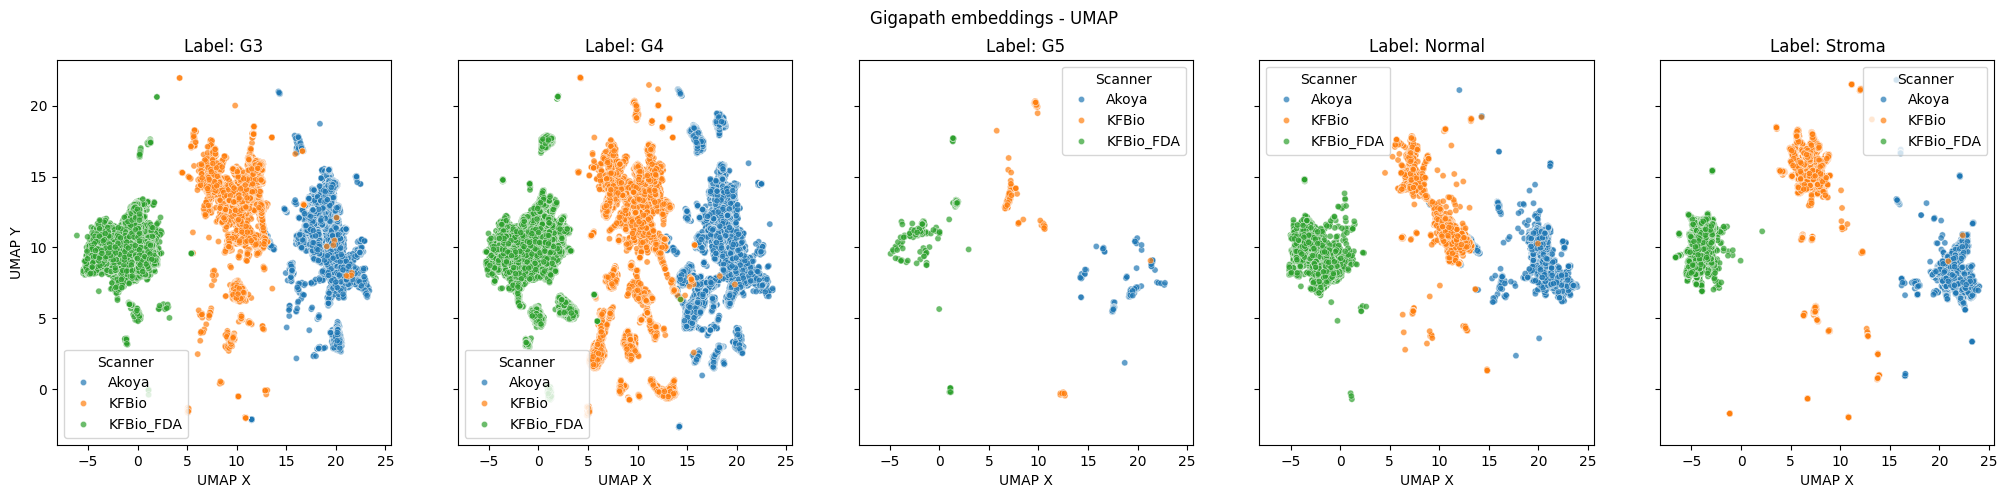

In [50]:
fig, axs = plt.subplots(1, n_labels, figsize=(5 * n_labels, 5), sharex=True, sharey=True)



for ax, label in zip(axs, unique_labels):
    data = df_all[df_all["label"] == label]
    sns.scatterplot(
        data=data,
        x="umap_x",
        y="umap_y",
        hue="scanner",
        ax=ax,
        s=20,
        alpha=0.7
    )
    ax.set_title(f"Label: {label}")
    ax.set_xlabel("UMAP X")
    ax.set_ylabel("UMAP Y")
    ax.legend(title="Scanner")

#plt.tight_layout()
plt.suptitle('Gigapath embeddings - UMAP')
plt.savefig("/home/leolr-int/nfs/ASTAR_internship/embeddings_gen/images/FDA_005_labels.png")
plt.show()


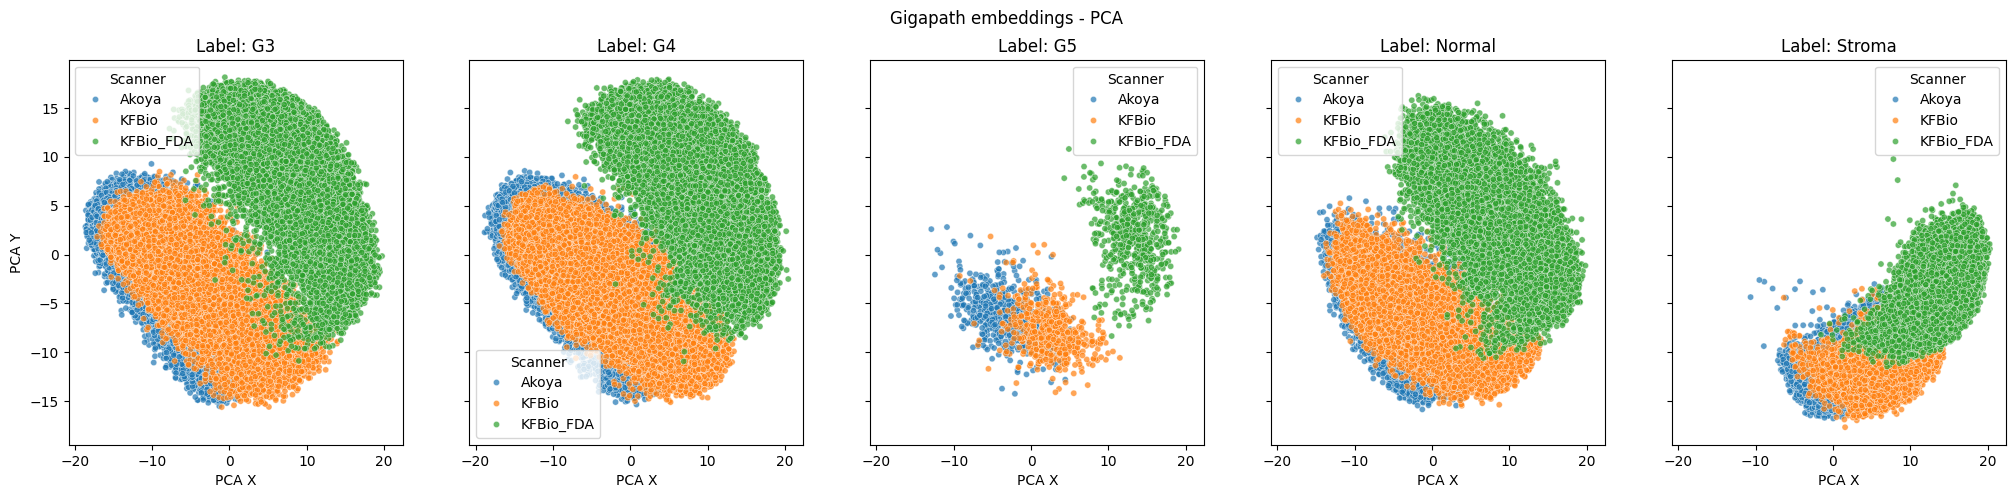

In [51]:
from sklearn.decomposition import PCA
import pandas as pd

# Assuming 'features' is your data matrix
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Add PCA results to your DataFrame
df_all["pca_x"] = pca_result[:, 0]
df_all["pca_y"] = pca_result[:, 1]

fig, axs = plt.subplots(1, n_labels, figsize=(5 * n_labels, 5), sharex=True, sharey=True)
for ax, label in zip(axs, unique_labels):
    data = df_all[df_all["label"] == label]
    sns.scatterplot(
        data=data,
        x="pca_x",  # Changed from "umap_x" to "pca_x"
        y="pca_y",  # Changed from "umap_y" to "pca_y"
        hue="scanner",
        ax=ax,
        s=20,
        alpha=0.7
    )
    ax.set_title(f"Label: {label}")
    ax.set_xlabel("PCA X")  # Changed from "UMAP X" to "PCA X"
    ax.set_ylabel("PCA Y")  # Changed from "UMAP Y" to "PCA Y"
    ax.legend(title="Scanner")

plt.suptitle('Gigapath embeddings - PCA')
#plt.savefig("/home/leolr-int/nfs/ASTAR_internship/embeddings_gen/images/FDA_005_labels.png")
plt.show()

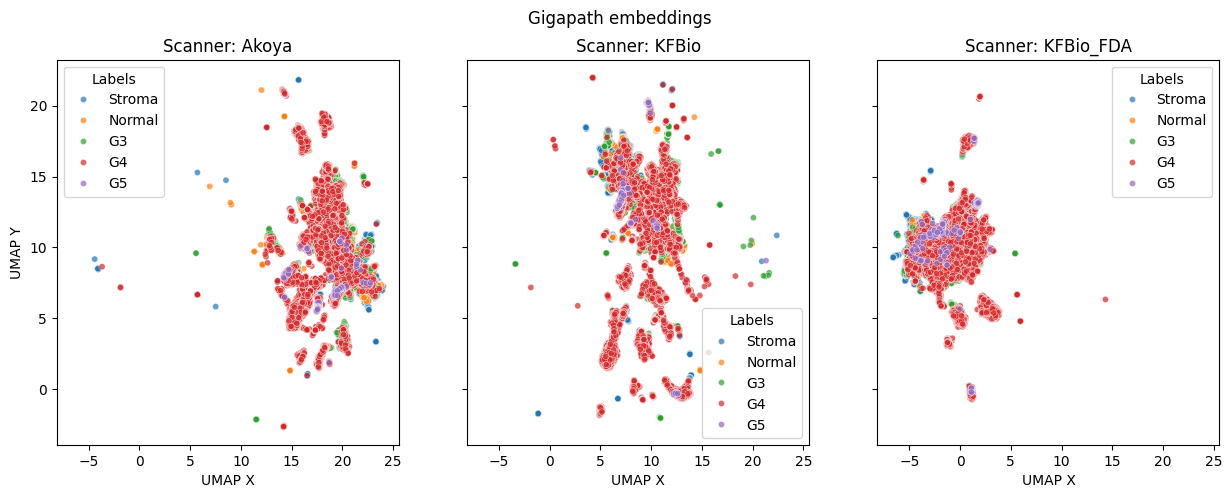

In [52]:
fig, axs = plt.subplots(1, 3, figsize=(5 * 3, 5), sharex=True, sharey=True)



for ax, scanner in zip(axs, scanners):
    data = df_all[df_all["scanner"] == scanner]
    sns.scatterplot(
        data=data,
        x="umap_x",
        y="umap_y",
        hue="label",
        ax=ax,
        s=20,
        alpha=0.7
    )
    ax.set_title(f"Scanner: {scanner}")
    ax.set_xlabel("UMAP X")
    ax.set_ylabel("UMAP Y")
    ax.legend(title="Labels")

#plt.tight_layout()
plt.suptitle('Gigapath embeddings')
plt.savefig("/home/leolr-int/nfs/ASTAR_internship/embeddings_gen/images/FDA_005_scanner.png")
plt.show()

In [45]:
from scipy.spatial.distance import mahalanobis
from itertools import combinations
from collections import defaultdict

# Store results per label
mahalanobis_results = defaultdict(dict)

for label in df_all["label"].unique():
    df_label = df_all[df_all["label"] == label]

    scanners_present = df_label["scanner"].unique()
    for s1, s2 in combinations(scanners_present, 2):
        emb1 = df_label[df_label["scanner"] == s1][["umap_x", "umap_y"]].values
        emb2 = df_label[df_label["scanner"] == s2][["umap_x", "umap_y"]].values

        # Compute pooled covariance matrix
        cov = np.cov(np.vstack((emb1, emb2)).T)
        cov_inv = np.linalg.pinv(cov)

        # Compute centroids
        mu1 = emb1.mean(axis=0)
        mu2 = emb2.mean(axis=0)

        dist = mahalanobis(mu1, mu2, cov_inv)

        mahalanobis_results[label][f"{s1} vs {s2}"] = dist

# Pretty print results
for label, dists in mahalanobis_results.items():
    print(f"\nLabel: {label}")
    for pair, dist in dists.items():
        print(f"  {pair}: {dist:.3f}")


Label: Stroma
  Akoya vs KFBio_FDA: 1.987

Label: Normal
  Akoya vs KFBio_FDA: 1.965

Label: G3
  Akoya vs KFBio_FDA: 1.969

Label: G4
  Akoya vs KFBio_FDA: 1.804

Label: G5
  Akoya vs KFBio_FDA: 1.978
